In [1]:
#necessary imports


from data_tools import query
from data_tools.collections import TimeSeries
import matplotlib.pyplot as plt
import pandas as pd
import dill
import os
import pytz
from datetime import datetime, time, date


In [ ]:
import torch

# General best practice for device setup
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available(): # For Apple Silicon GPUs
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")


In [ ]:
# query data from influx. looking at timestamps of 2024 FSGP: 14 - 18 overall, but for smaller data response lets try 14 -16

#each 5 seconds
utc_offset_h = 7
start_utc = time(0+utc_offset_h, 00, 00)  #querying i svancouver time, influxdb gives utc
stop_utc = time(16+utc_offset_h, 45, 00)
date_start = date(2024, 7, 16)
date_stop = date(2024, 7, 18)

vancouver = pytz.timezone("America/Vancouver")

start_local = vancouver.localize(datetime.combine(date_start, start_utc))
stop_local = vancouver.localize(datetime.combine(date_stop, stop_utc))

start_time = start_local.astimezone(pytz.utc)
stop_time = stop_local.astimezone(pytz.utc)

client = query.DBClient()
mech_brake_pressed: TimeSeries = client.query_time_series(start_time, stop_time, field="MechBrakePressed")
accel_position: TimeSeries =   client.query_time_series(start_time, stop_time, field="AcceleratorPosition")
speed_kph: TimeSeries = client.query_time_series(start_time, stop_time, "VehicleVelocity")



In [2]:
#loading data
import os
import dill
out_dir = os.path.join("../../array_temp", "data", "control_state_fsgp_2024")

brake_path = os.path.join(out_dir, "brake_pressed.bin")
accel_path = os.path.join(out_dir, "acceleration.bin")
speed_path = os.path.join(out_dir, "speed_kph.bin")

filepaths = [brake_path, accel_path, speed_path]

loaded_datasets = []

for filepath in filepaths:
    with open(filepath, "rb") as f:
        data = dill.load(f)
        loaded_datasets.append(data)

#unnpack
mech_brake_pressed, accel_position, speed_kph = loaded_datasets

In [3]:
# use sunbeam instead to save yourself a headache
def make_df(source, name):
    dfs = []

    client = query.SunbeamClient()

    for event in ["FSGP_2024_Day_1", "FSGP_2024_Day_2", "FSGP_2024_Day_3"]:
        file = client.get_file(
            origin="production",
            event=event,
            source=source,
            name=name
        ).unwrap()

        dfs.append(
            pd.DataFrame(
                data=file.data,
                index=file.data.datetime_x_axis
            )
        )

    return pd.concat(dfs).sort_index()

In [4]:
# combine all dfs and resample, then feed to scaler.
# states = velocity, position
# control = mbrake pressed, accelerator position
def combine_dfs(telemetry_names, index_common, all_dfs):
        combined_df = pd.DataFrame(index=index_common)
        combined_df.dropna()

        for name, df in zip(telemetry_names, all_dfs):
            #df_interp = self.resample(df, index_common)
            combined_df[name] = df

        return combined_df


In [5]:

pos_df = make_df(source = "localization", name = "TrackIndex")
speed_df = make_df(source = "ingress", name = "VehicleVelocity")
#preprocessing - convert everything to pandas dataframes.


df_mech_brake_pressed = pd.DataFrame(mech_brake_pressed, index = mech_brake_pressed.datetime_x_axis)
df_accel_position = pd.DataFrame(accel_position, index = accel_position.datetime_x_axis)
#df_speed_kph = pd.DataFrame(speed_kph)



all_dfs = [df_mech_brake_pressed, df_accel_position]
combined_df = combine_dfs(["mech_brake_pressed", "accel_position"], df_mech_brake_pressed.index, all_dfs)
final_df = pd.merge_asof(
    df_mech_brake_pressed.sort_index(),
    df_accel_position.sort_index(),
    left_index=True,
    right_index=True,
    direction="nearest"
)

In [6]:
dfs = pd.concat([pos_df, speed_df], axis = 1)
final_df = pd.merge_asof(
    final_df.sort_index(),
    dfs.sort_index(),
    left_index=True,
    right_index=True,
    direction="nearest"
)
final_df.columns = ["brake_pressed", "accel_position", "position", "speed"]

In [7]:
final_df.head()

,brake_pressed,accel_position,position,speed
2024-07-16 07:05:27.380000114,0.0,0.0,0.0,0.0
2024-07-16 07:05:27.480000019,0.0,0.0,0.0,0.0
2024-07-16 07:05:27.580000162,0.0,0.0,0.0,0.0
2024-07-16 07:05:27.680000067,0.0,0.0,0.0,0.0
2024-07-16 07:05:27.780000210,0.0,0.0,0.0,0.0


In [ ]:
print(final_df.isna().sum())
print(final_df.shape)
# position has nan values

In [8]:
final_df = final_df.sort_index()
final_df = final_df.ffill().dropna()

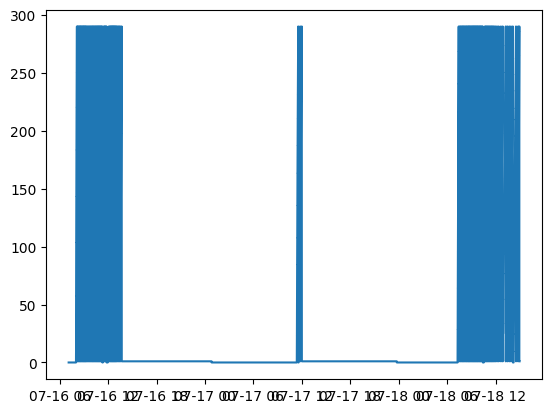

In [10]:
plt.plot(final_df["position"])

In [9]:
#finally cleared up all data, now move onto RNN
from control_model import DataPreprocessing

train_dataset, test_dataset, train_loader, test_loader, scaler = DataPreprocessing.make_sequence_datasets(final_df, state_cols = ['position', 'speed'], control_cols = ['brake_pressed', 'accel_position'], seq_len = 1000, train_frac=0.7, batch_size = 128)

In [10]:
state = ['position', 'speed']
control = ['brake_pressed', 'accel_position']

In [11]:
import time

# Test 1: raw tensor indexing speed (no dataloader at all)
t = time.time()
for i in range(5):
    idx = train_dataset.indices[i]
    x = train_dataset.states[idx:idx+train_dataset.seq_len]
    y = train_dataset.controls[idx:idx+train_dataset.seq_len]
print(f"Raw tensor access (5 samples): {time.time()-t:.4f}s")

# Test 2: dataset __getitem__ speed
t = time.time()
for i in range(5):
    x, y = train_dataset[i]
print(f"Dataset __getitem__ (5 samples): {time.time()-t:.4f}s")

# Test 3: dataloader speed
t = time.time()
for i, (x, y) in enumerate(train_loader):
    if i == 5: break
print(f"DataLoader (5 batches): {time.time()-t:.4f}s")

# Test 4: how big is your data?
print(f"\nTotal sequences: {len(train_dataset)}")
print(f"Batches per epoch: {len(train_loader)}")
print(f"states tensor size: {train_dataset.states.shape}")
print(f"controls tensor size: {train_dataset.controls.shape}")

Raw tensor access (5 samples): 0.0121s
Dataset __getitem__ (5 samples): 0.0138s
DataLoader (5 batches): 0.0408s

Total sequences: 14074
Batches per epoch: 110
states tensor size: torch.Size([1408361, 2])
controls tensor size: torch.Size([1408361, 2])


C:\Users\sanar\PycharmProjects\data_analysis\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [12]:

from control_model.RNN import *
seq_length = 1000
input_size = len(state)
output_size = len(control)


hidden_size = 128     # was 256
num_layers  = 2
model = RNN(input_size, hidden_size, num_layers, seq_length, output_size).to(device)

In [13]:
# now we define the training loop. we are pretending a trajectory of controls.
#build the model
def train_model(model, train_loader, test_loader, epochs):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
    train_losses = []
    test_losses = []
    print("NaNs in Train Loader:", any(torch.isnan(x).any() for x, y in train_loader))
    print("NaNs in Test Loader:", any(torch.isnan(x).any() for x, y in test_loader))
    for epoch in range(epochs):

        #training loop
        model.train()
        train_loss = 0
        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            #check inputs before forward pass
            if torch.isnan(x_batch).any() or torch.isnan(y_batch).any():
                print("NaN in inputs, skipping batch")
                continue


            optimizer.zero_grad() #resets the gradients to zero
            outputs = model(x_batch)
            loss = criterion(outputs, y_batch)
            if torch.isnan(outputs).any():
                print("NaN in model outputs")
                print("x_batch min/max:", x_batch.min().item(), x_batch.max().item())
                continue

            loss = criterion(outputs, y_batch)

            if torch.isnan(loss):
                print("NaN in loss")
                print("outputs min/max:", outputs.min().item(), outputs.max().item())
                print("y_batch min/max:", y_batch.min().item(), y_batch.max().item())
                continue
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1)
            optimizer.step()

            train_loss += loss.item() #convert tensor to float
        train_loss/=len(train_loader) #average losses over batches
        print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {train_loss:.4f}")
        train_losses.append(train_loss)

        # testing loop
        model.eval()
        test_loss = 0
        with torch.no_grad():
            for x_batch, y_batch in test_loader:
                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)
                optimizer.zero_grad()
                predictions = model(x_batch)
                loss = criterion(predictions, y_batch)
                test_loss += loss.item()
        test_loss/=len(test_loader)
        test_losses.append(test_loss)

    return train_losses, test_losses

In [14]:
train_losses, test_losses = train_model(model, train_loader, test_loader, epochs=10)

# Save
torch.save({
    'model_state_dict': model.state_dict(),
    'input_size': input_size,
    'hidden_size': hidden_size,
    'num_layers': num_layers,
    'seq_length': seq_length,
    'output_size': output_size,
}, '../array_temp/rnn_model.pt')

C:\Users\sanar\PycharmProjects\data_analysis\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


NaNs in Train Loader: False
NaNs in Test Loader: False
Epoch 1/10, Train Loss: 0.8426
Epoch 2/10, Train Loss: 0.7102
Epoch 3/10, Train Loss: 0.7090
Epoch 4/10, Train Loss: 0.7085
Epoch 5/10, Train Loss: 0.7083
Epoch 6/10, Train Loss: 0.7076
Epoch 7/10, Train Loss: 0.7072
Epoch 8/10, Train Loss: 0.7068
Epoch 9/10, Train Loss: 0.7065
Epoch 10/10, Train Loss: 0.7053


In [15]:
print(test_losses)

[0.7880346009042114, 0.7750665485315645, 0.7742923867966359, 0.7722918457972506, 0.7733135666542997, 0.7732195612043142, 0.7729957114206627, 0.7712206876603886, 0.7692550068022683, 0.7723857162830731]


In [18]:
#remember we also need to save the scaler to apply at inference
#using job lib for this purpose
import joblib
joblib.dump(scaler, 'scaler.pkl')

# Later at inference
scaler = joblib.load('scaler.pkl')
x_new_scaled = scaler.transform(x)

C:\Users\sanar\PycharmProjects\data_analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


ValueError: Found array with dim 3, while dim <= 2 is required by StandardScaler.

In [16]:
#now we evaluate model for inference
checkpoint = torch.load('../array_temp/rnn_model.pt', map_location=device)

model = RNN(
    input_size  = checkpoint['input_size'],
    hidden_size = checkpoint['hidden_size'],
    num_layers  = checkpoint['num_layers'],
    seq_length  = checkpoint['seq_length'],
    output_size = checkpoint['output_size'],
)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()  # important — disables dropout/batchnorm for inference

RNN(
  (lstm): LSTM(2, 128, num_layers=2, batch_first=True)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)

In [17]:
import matplotlib.pyplot as plt
import numpy as np

def plot_control_trajectory(model, test_dataset, scaler, state_cols, control_cols, sample_idx):
    model.eval()
    x_input, y_target = test_dataset[sample_idx]

# x_input should be [seq_len, n_states]
    print(x_input.shape)

    x_np = x_input.numpy()  # [seq_len, n_states]

    # derive time axes from actual array shapes, not seq_len variable
    time_controls = np.arange(y_target.shape[0]) * 0.1
    time_states   = np.arange(x_np.shape[0]) * 0.1
    x_input, y_target = test_dataset[sample_idx]

    with torch.no_grad():
        device = next(model.parameters()).device
        x_tensor = x_input.to(device).unsqueeze(0)
        y_pred = model(x_tensor).squeeze(0).cpu().numpy()

    y_target = y_target.numpy()
    x_np = x_input.numpy()  # [seq_len, n_states]

    # inverse transform controls
    # scaler was fit on state_cols + control_cols so controls start at index n_states
    n_states = len(state_cols)
    n_controls = len(control_cols)
    seq_len = 1000
    def unscale_states(arr):
        state_mean = scaler.mean_[:n_states]
        state_std  = scaler.scale_[:n_states]
        return arr * state_std + state_mean
    def unscale_controls(arr):
        dummy = np.zeros((seq_len, n_states + n_controls))
        dummy[:, n_states:] = arr
        return scaler.inverse_transform(dummy)[:, n_states:]

    y_target_unscaled = unscale_controls(y_target)
    y_pred_unscaled   = unscale_controls(y_pred)
    x_unscaled        = unscale_states(x_np)

    time_controls = np.arange(seq_len) * 0.1
    time_states   = np.arange(x_np.shape[0]) * 0.1

    # plot controls
    fig, axes = plt.subplots(n_controls, 1, figsize=(10, 4 * n_controls), sharex=True)
    if n_controls == 1:
        axes = [axes]

    for i, col in enumerate(control_cols):
        axes[i].plot(time_controls, y_target_unscaled[:, i], 'g-', label='Actual (Driver)')
        axes[i].plot(time_controls, y_pred_unscaled[:, i], 'r--', label='Predicted (RNN)')
        axes[i].set_ylabel(col)
        axes[i].legend()
        axes[i].grid(True)

    axes[-1].set_xlabel("Time (seconds)")
    plt.suptitle(f"Control Trajectory — Sample {sample_idx}")
    plt.tight_layout()

    # plot states
    fig2, axes2 = plt.subplots(n_states, 1, figsize=(10, 4 * n_states), sharex=True)
    if n_states == 1:
        axes2 = [axes2]
    print(x_np.shape)        # should be [seq_len, n_states]
    print(x_unscaled.shape)  # should match
    print(time_states.shape)
    for i, col in enumerate(state_cols):
        axes2[i].plot(time_states, x_unscaled[:, i], 'b-', label=col)
        axes2[i].set_ylabel(col)
        axes2[i].legend()
        axes2[i].grid(True)

    axes2[-1].set_xlabel("Time (seconds)")
    plt.suptitle(f"Input State Sequence — Sample {sample_idx}")
    plt.tight_layout()
    plt.show()

In [18]:
for i in range(len(test_dataset)):
    x, y = test_dataset[i]
    if y.abs().mean() >= .960:
        print(f"use sample_idx={i}")
        break

use sample_idx=3137


torch.Size([1000, 2])
(1000, 2)
(1000, 2)
(1000,)


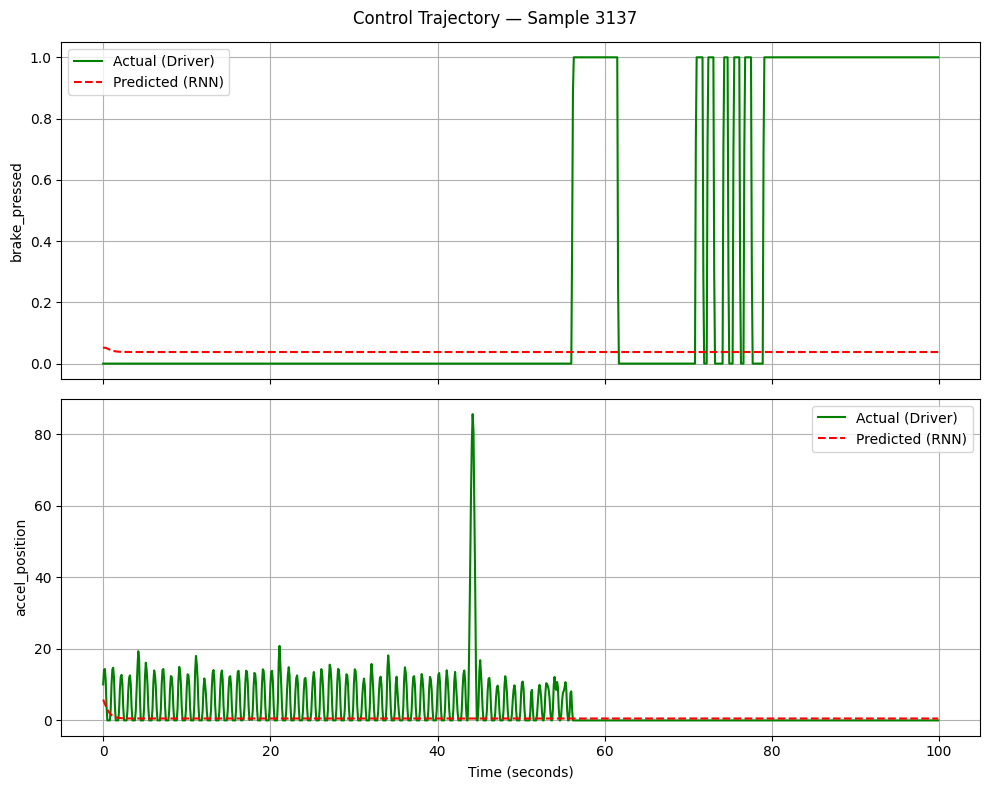

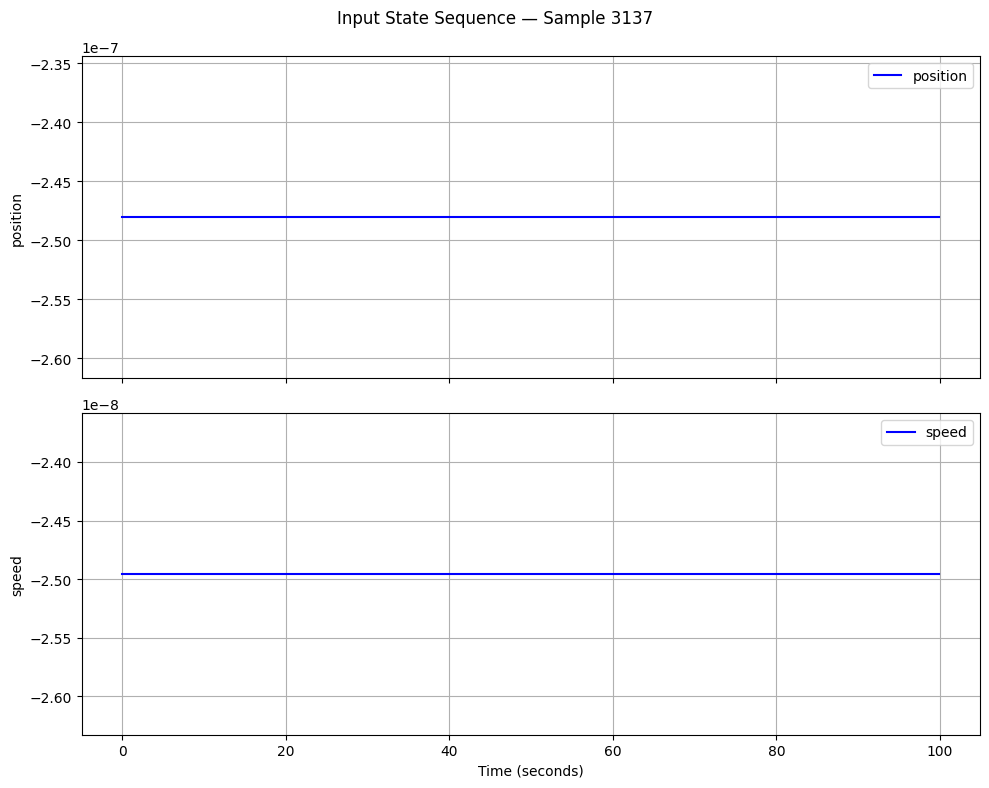

torch.Size([1000, 2])
(1000, 2)
(1000, 2)
(1000,)


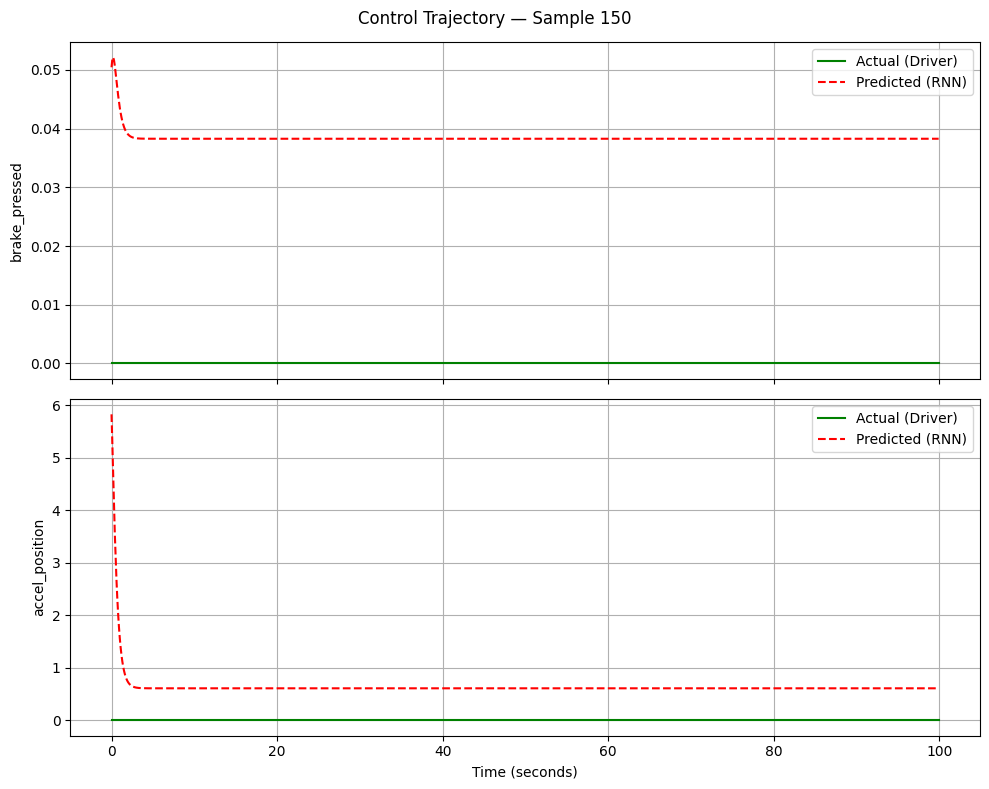

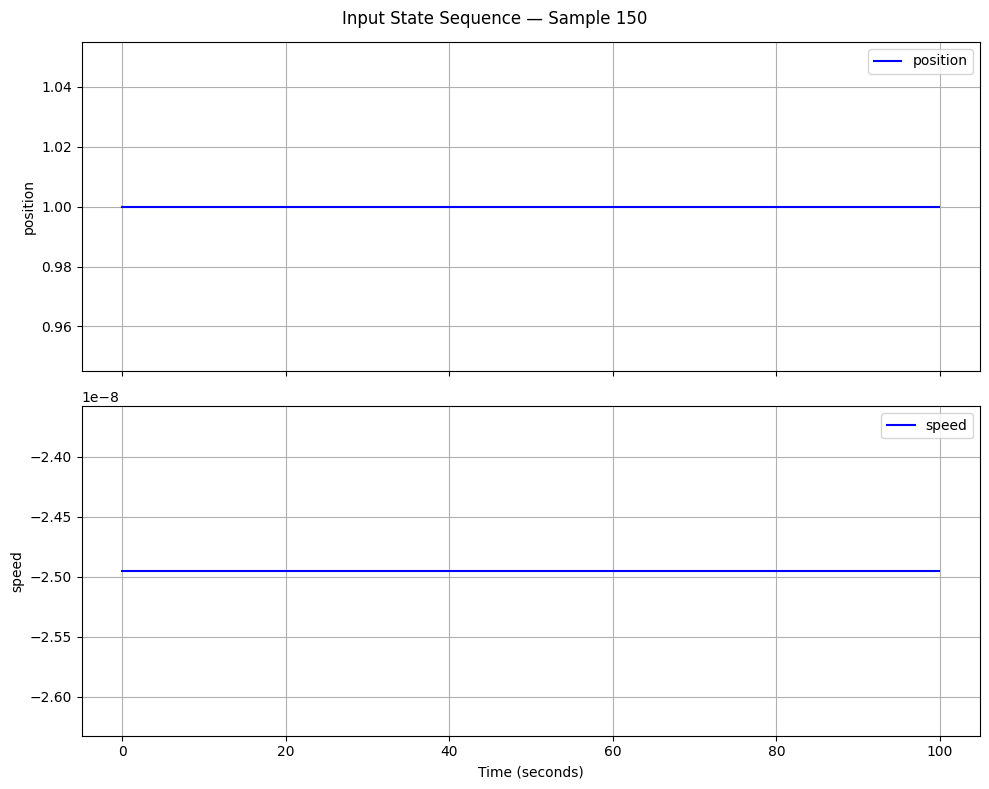

In [19]:
state_cols = ['position', 'speed']
control_cols = ['brake_pressed', 'accel_position']
plot_control_trajectory(model, test_dataset, scaler, state_cols, control_cols, sample_idx=3137)
plot_control_trajectory(model, test_dataset, scaler, state_cols, control_cols, sample_idx=150)

In [ ]:
# so how much does scaling the acceleraotr position before hand matter? why has the training time increased so much

In [ ]:
print("Any inf in final_df:", np.isinf(final_df.values).any())
print("Any NaN in final_df:", np.isnan(final_df.values).any())